# 🏠 House Price Prediction

An end-to-end Machine Learning project using the **Ames Housing dataset**.

This notebook demonstrates a complete regression workflow:

1. Exploratory Data Analysis
2. Feature Engineering
3. Multiple regression model benchmarking
4. Cross-validation
5. Hyperparameter tuning
6. Error analysis
7. Model explainability with SHAP

---
## 1. Import Libraries

We begin by importing all necessary libraries for data analysis, preprocessing,
visualization, machine learning, and model evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
from pathlib import Path
from scipy import stats
from functools import reduce
from operator import mul

warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split, KFold, cross_validate, RandomizedSearchCV,
)
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.base import clone

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor, HistGradientBoostingRegressor,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

import joblib

# Optional dependencies
try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
    print("✓ XGBoost available")
except ImportError:
    HAS_XGBOOST = False
    print("✗ XGBoost not installed — install with: pip install xgboost")

try:
    import shap
    HAS_SHAP = True
    print("✓ SHAP available")
except ImportError:
    HAS_SHAP = False
    print("✗ SHAP not installed — install with: pip install shap")

✓ XGBoost available
✓ SHAP available


In [2]:
# Configuration
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_SPLITS = 5
np.random.seed(RANDOM_STATE)

# Plot settings
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100

# Create output directories
Path("../reports/figures").mkdir(parents=True, exist_ok=True)
Path("../models").mkdir(parents=True, exist_ok=True)

print(f"Random state: {RANDOM_STATE}")
print(f"Test size:    {TEST_SIZE}")
print(f"CV folds:     {N_SPLITS}")

Random state: 42
Test size:    0.2
CV folds:     5


---
## 2. Load the Dataset

We load the Kaggle Ames Housing training dataset.
Each row represents a house and each column is a feature describing the property.

In [3]:
df = pd.read_csv("../data/train.csv")
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 1460 rows × 81 columns


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
## 3. Data Understanding

In [4]:
print("Data types summary:")
print(f"  Numerical features:   {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"  Categorical features: {len(df.select_dtypes(exclude=[np.number]).columns)}")
print(f"\nTarget variable: SalePrice")
print(f"  Range: ${df['SalePrice'].min():,} – ${df['SalePrice'].max():,}")

Data types summary:
  Numerical features:   38
  Categorical features: 43

Target variable: SalePrice
  Range: $34,900 – $755,000


In [5]:
df.describe().round(1)

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.0,1460.0,1201.0,1460.0,1460.0,1460.0,1460.0,1460.0,1452.0,1460.0,...,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0
mean,730.5,56.9,70.0,10516.8,6.1,5.6,1971.3,1984.9,103.7,443.6,...,94.2,46.7,22.0,3.4,15.1,2.8,43.5,6.3,2007.8,180921.2
std,421.6,42.3,24.3,9981.3,1.4,1.1,30.2,20.6,181.1,456.1,...,125.3,66.3,61.1,29.3,55.8,40.2,496.1,2.7,1.3,79442.5
min,1.0,20.0,21.0,1300.0,1.0,1.0,1872.0,1950.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2006.0,34900.0
25%,365.8,20.0,59.0,7553.5,5.0,5.0,1954.0,1967.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,2007.0,129975.0
50%,730.5,50.0,69.0,9478.5,6.0,5.0,1973.0,1994.0,0.0,383.5,...,0.0,25.0,0.0,0.0,0.0,0.0,0.0,6.0,2008.0,163000.0
75%,1095.2,70.0,80.0,11601.5,7.0,6.0,2000.0,2004.0,166.0,712.2,...,168.0,68.0,0.0,0.0,0.0,0.0,0.0,8.0,2009.0,214000.0
max,1460.0,190.0,313.0,215245.0,10.0,9.0,2010.0,2010.0,1600.0,5644.0,...,857.0,547.0,552.0,508.0,480.0,738.0,15500.0,12.0,2010.0,755000.0


In [6]:
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 0


---
## 4. Data Quality & Missing Values

Understanding missing values is critical in the Ames Housing dataset because
many NaN values carry **semantic meaning** — they indicate the *absence* of a
feature (e.g. no pool, no garage), not unknown data.

In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({"Count": missing, "Percent": missing_pct})
print(f"Features with missing values: {len(missing_df)} out of {df.shape[1]}")
missing_df

Features with missing values: 19 out of 81


,Count,Percent
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageType,81,5.5
GarageYrBlt,81,5.5
GarageFinish,81,5.5


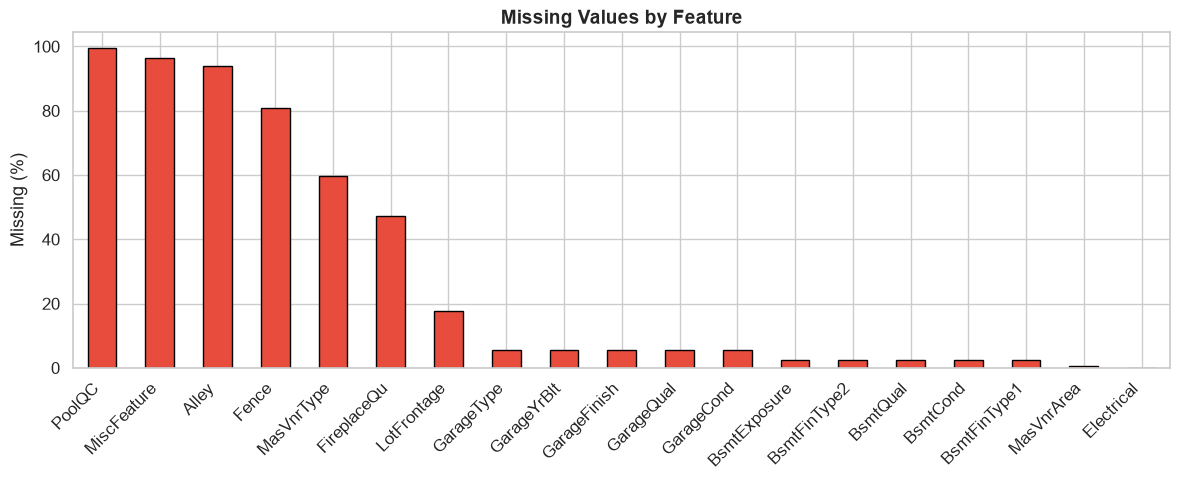

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
missing_df["Percent"].plot(kind="bar", ax=ax, color="#e74c3c", edgecolor="black")
ax.set_title("Missing Values by Feature", fontsize=14, fontweight="bold")
ax.set_ylabel("Missing (%)")
ax.set_xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../reports/figures/missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

**Missing Value Interpretation (Domain Knowledge):**

| Feature Group | Examples | NaN Meaning |
|---|---|---|
| Pool | PoolQC | No pool |
| Garage | GarageType, GarageFinish, GarageQual, GarageCond | No garage |
| Basement | BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1/2 | No basement |
| Fireplace | FireplaceQu | No fireplace |
| Lot | Alley, Fence | No alley / no fence |
| Masonry | MasVnrType, MasVnrArea | No masonry veneer |
| Misc | MiscFeature | No misc feature |
| LotFrontage | — | Genuinely missing (will use median imputation) |
| Electrical | — | 1 missing value (will use mode) |

→ These NaN values will be handled with **domain-aware preprocessing** before modeling.

---
## 5. Exploratory Data Analysis
### 5.1 Target Analysis

`SalePrice` is the target variable for regression.
We examine its distribution and skewness.

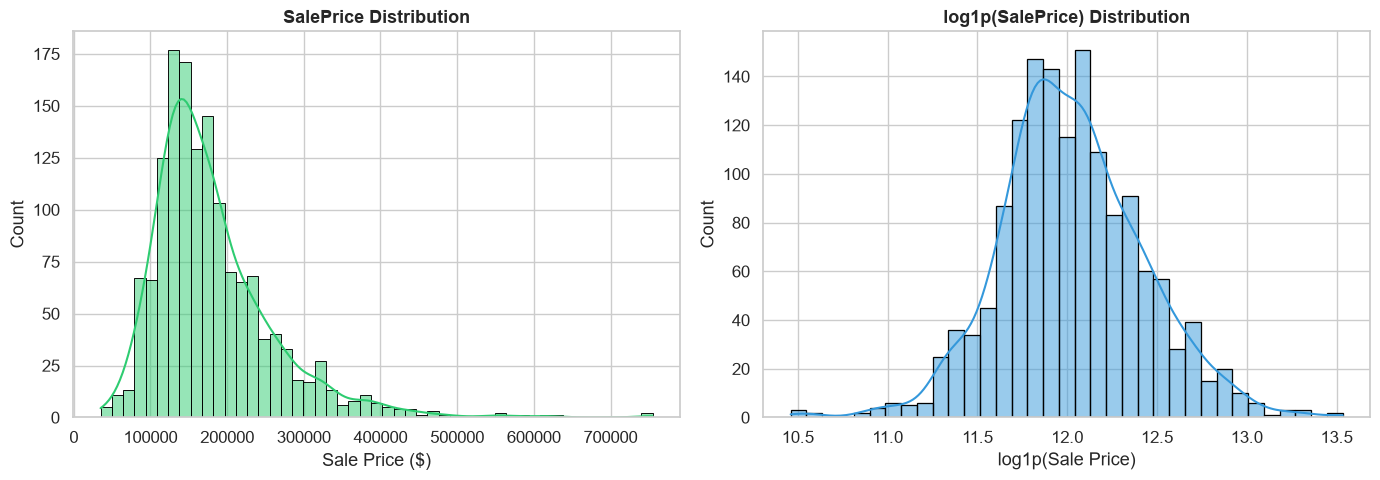

SalePrice Statistics:
  Mean:     $180,921
  Median:   $163,000
  Std Dev:  $79,443
  Skewness: 1.88
  Kurtosis: 6.54


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["SalePrice"], kde=True, ax=axes[0], color="#2ecc71", edgecolor="black")
axes[0].set_title("SalePrice Distribution", fontweight="bold")
axes[0].set_xlabel("Sale Price ($)")

sns.histplot(np.log1p(df["SalePrice"]), kde=True, ax=axes[1], color="#3498db", edgecolor="black")
axes[1].set_title("log1p(SalePrice) Distribution", fontweight="bold")
axes[1].set_xlabel("log1p(Sale Price)")

plt.tight_layout()
plt.savefig("../reports/figures/target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("SalePrice Statistics:")
print(f"  Mean:     ${df['SalePrice'].mean():,.0f}")
print(f"  Median:   ${df['SalePrice'].median():,.0f}")
print(f"  Std Dev:  ${df['SalePrice'].std():,.0f}")
print(f"  Skewness: {df['SalePrice'].skew():.2f}")
print(f"  Kurtosis: {df['SalePrice'].kurtosis():.2f}")

The target is **right-skewed** (skewness > 1). The log-transformed version is closer
to a normal distribution. We will **experimentally compare** raw vs. log-transformed
targets later to determine which produces better regression performance.

### 5.2 Numerical Feature Analysis

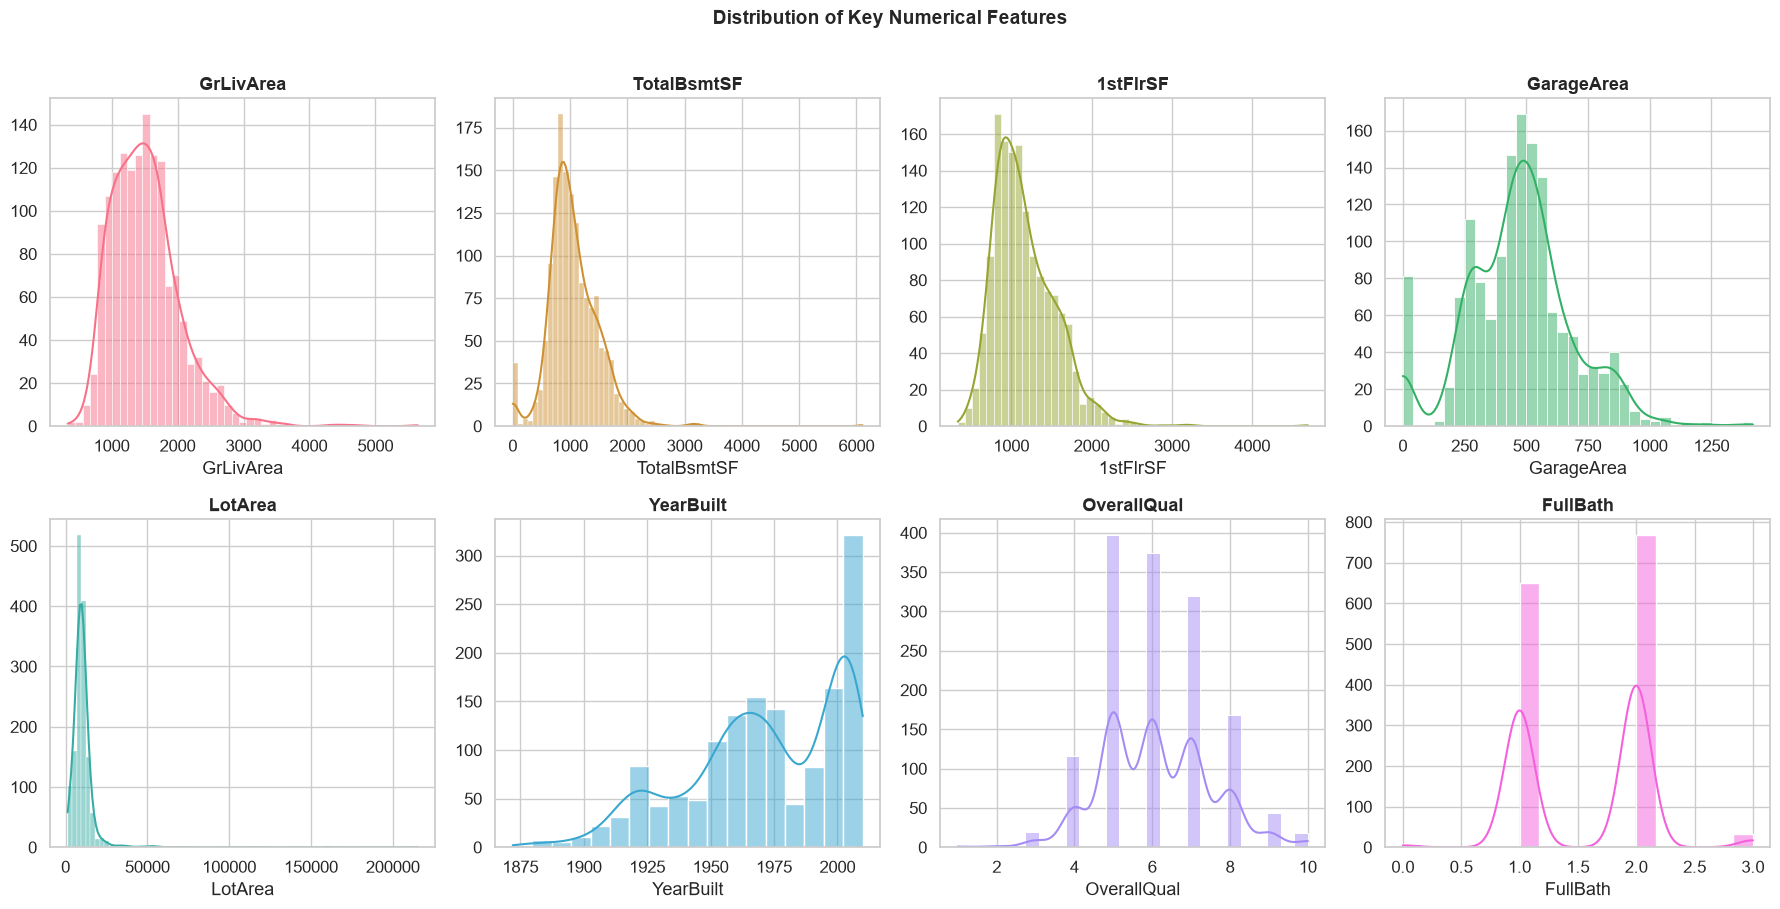

In [10]:
key_numerical = ["GrLivArea", "TotalBsmtSF", "1stFlrSF", "GarageArea",
                 "LotArea", "YearBuilt", "OverallQual", "FullBath"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for i, col in enumerate(key_numerical):
    ax = axes[i // 4][i % 4]
    sns.histplot(df[col], kde=True, ax=ax, color=sns.color_palette("husl", 8)[i])
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("")
plt.suptitle("Distribution of Key Numerical Features", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 5.3 Categorical Feature Analysis

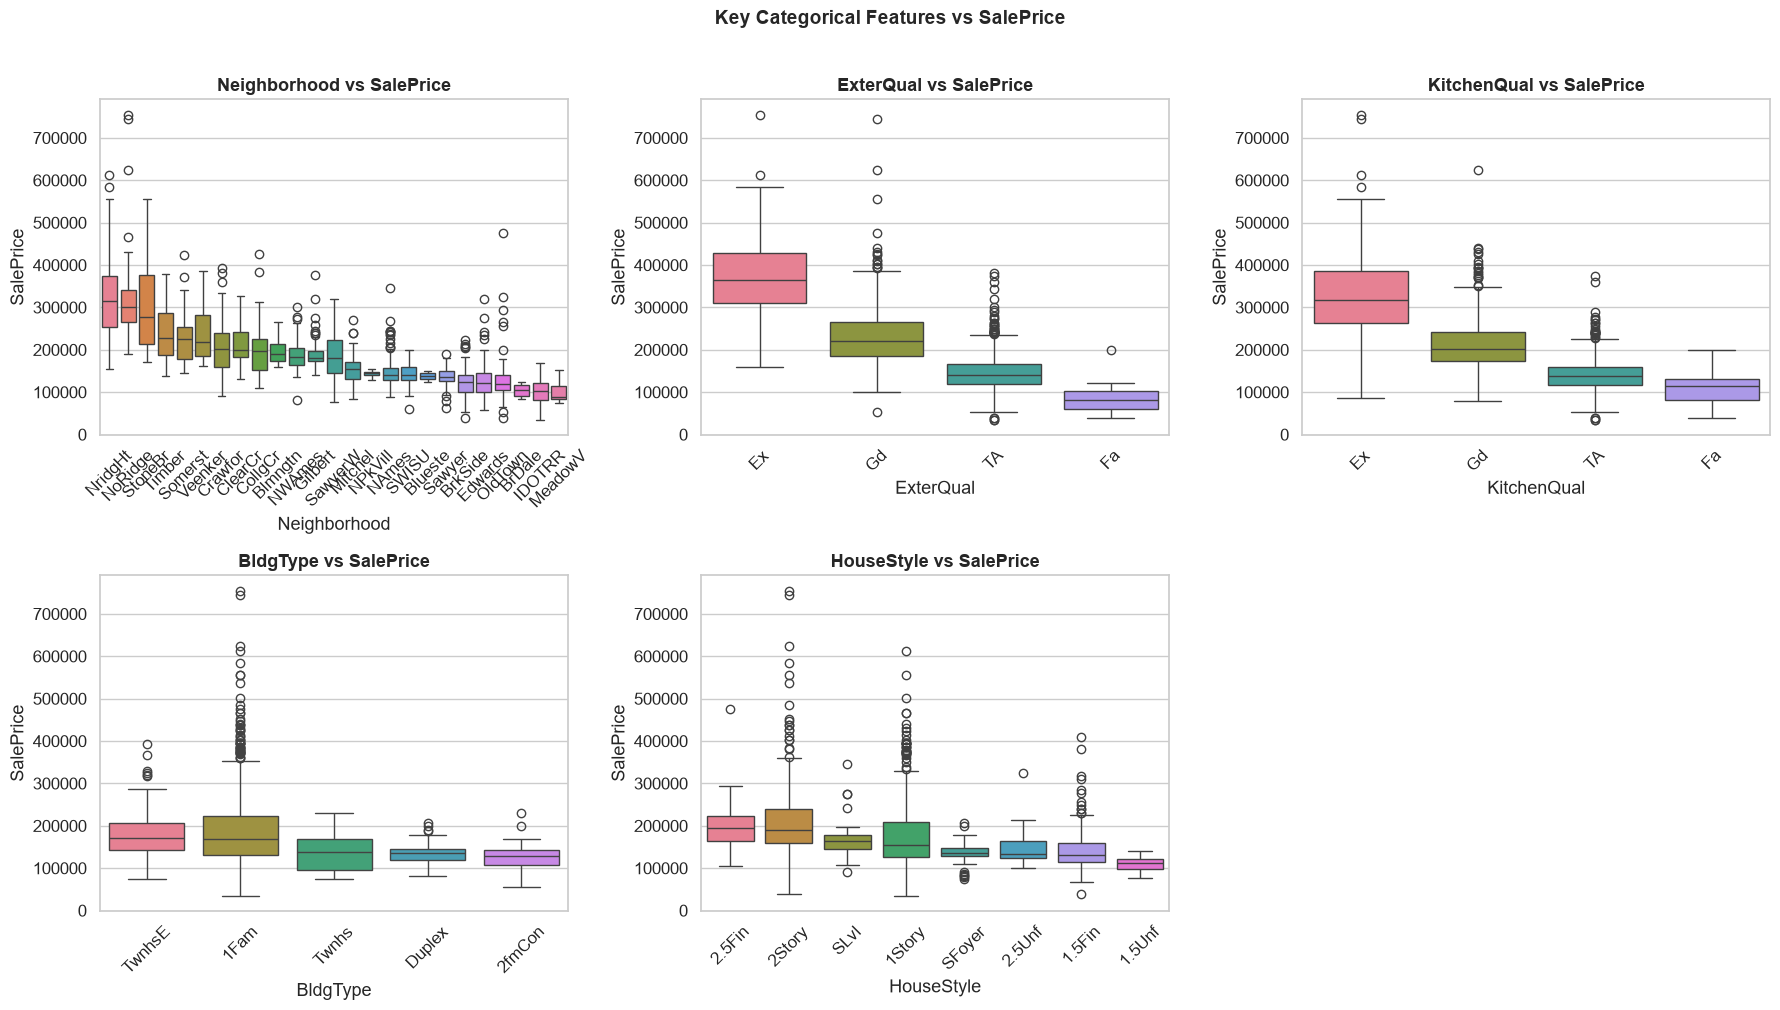

In [11]:
key_categorical = ["Neighborhood", "ExterQual", "KitchenQual", "BldgType", "HouseStyle"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()
for i, col in enumerate(key_categorical):
    order = df.groupby(col)["SalePrice"].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y="SalePrice", order=order, ax=axes_flat[i], palette="husl")
    axes_flat[i].set_title(f"{col} vs SalePrice", fontweight="bold")
    axes_flat[i].tick_params(axis="x", rotation=45)
axes_flat[5].axis("off")
plt.suptitle("Key Categorical Features vs SalePrice", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

`OverallQual`, `ExterQual`, and `KitchenQual` show strong ordering with price —
higher quality consistently maps to higher sale prices. `Neighborhood` has
significant price variation, making it an important categorical predictor.

### 5.4 Correlation Analysis

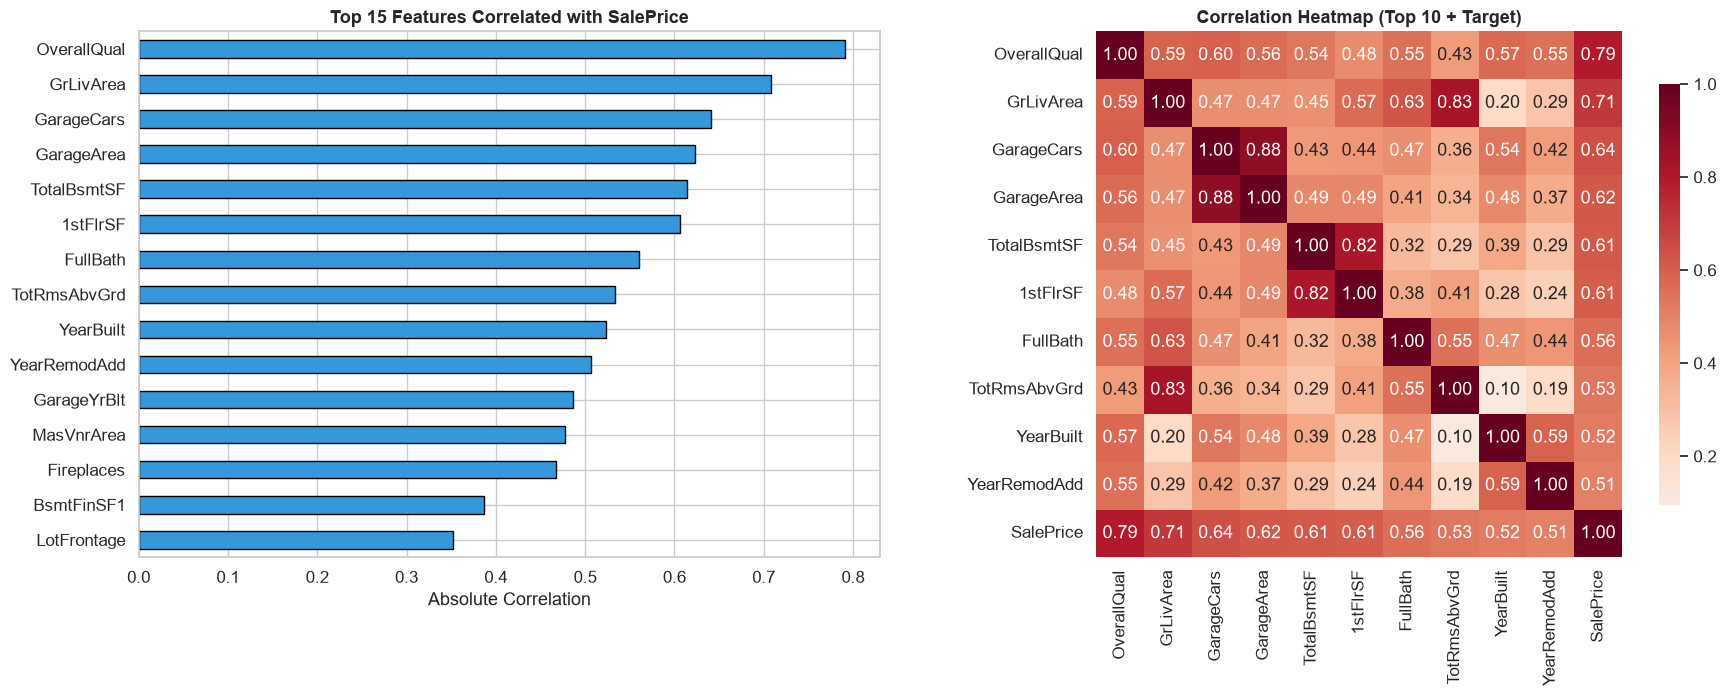

In [12]:
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()["SalePrice"].drop("SalePrice").abs().sort_values(ascending=False)
top_corr = correlations.head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top_corr.plot(kind="barh", ax=axes[0], color="#3498db", edgecolor="black")
axes[0].set_title("Top 15 Features Correlated with SalePrice", fontweight="bold")
axes[0].set_xlabel("Absolute Correlation")
axes[0].invert_yaxis()

top_features = correlations.head(10).index.tolist() + ["SalePrice"]
sns.heatmap(df[top_features].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=axes[1], square=True, cbar_kws={"shrink": 0.8})
axes[1].set_title("Correlation Heatmap (Top 10 + Target)", fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/correlation_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

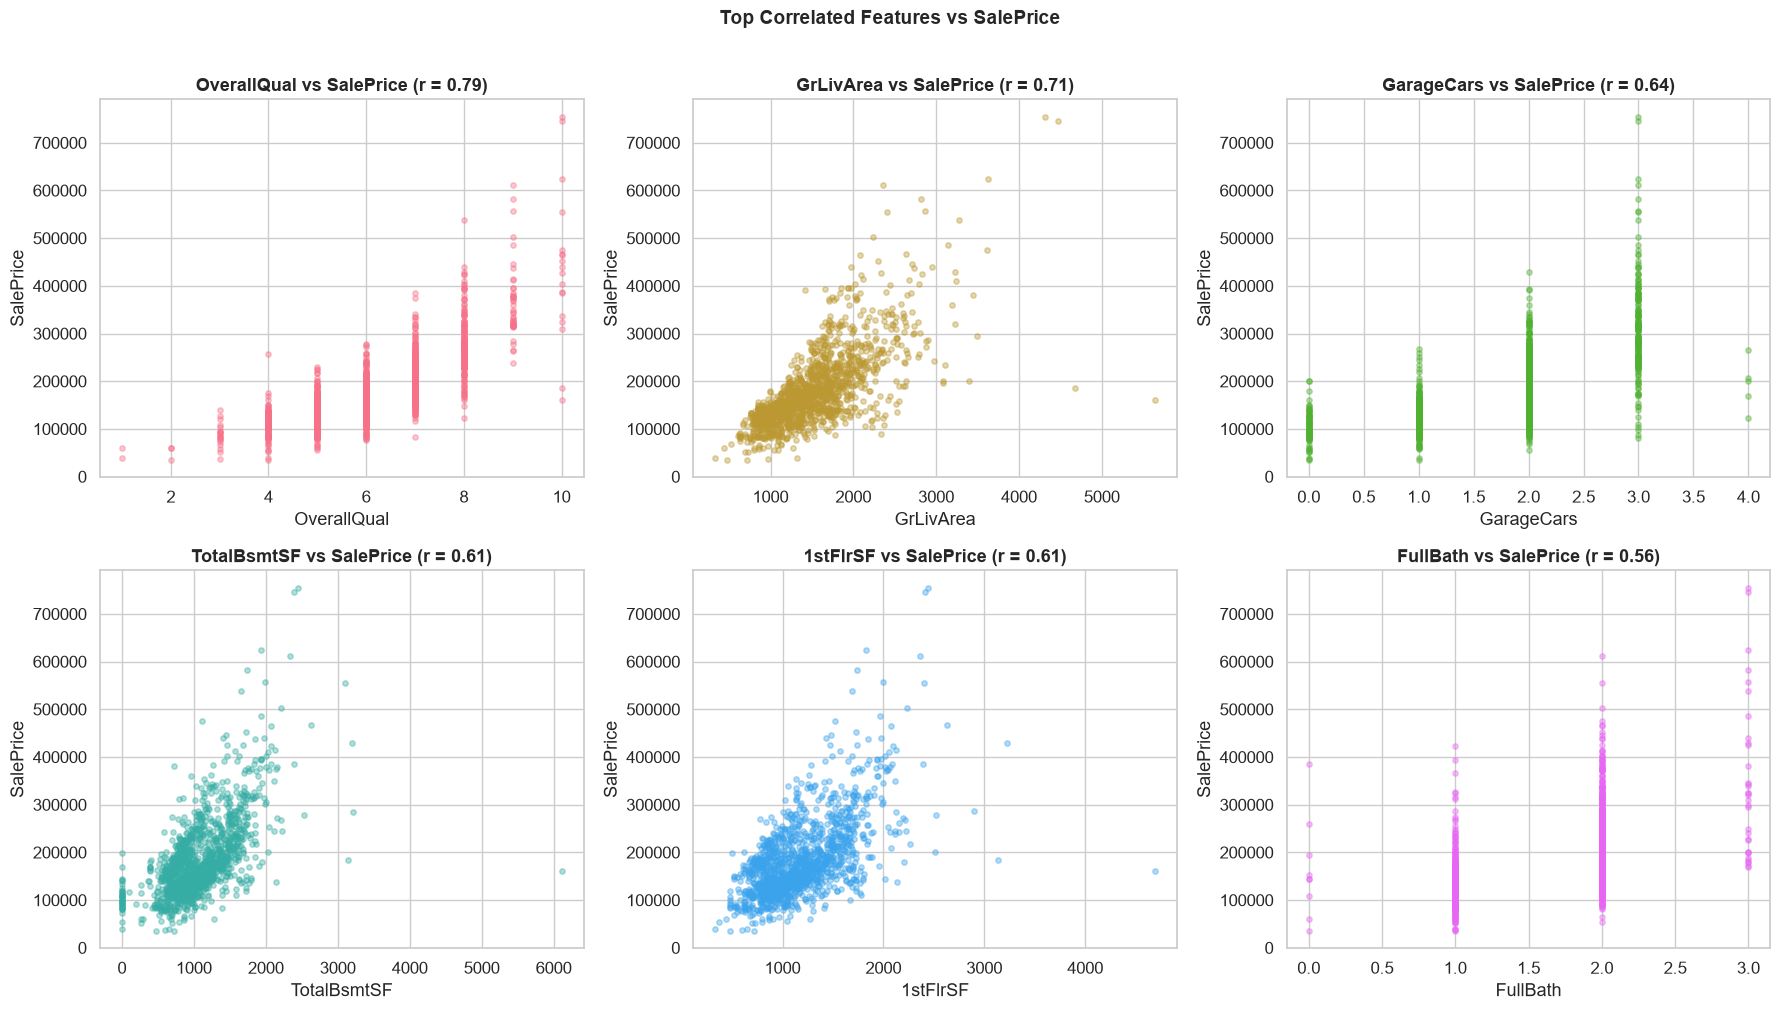

In [13]:
# Key scatterplots of top correlated features vs SalePrice
top_scatter = ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "1stFlrSF", "FullBath"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(top_scatter):
    ax = axes[i // 3][i % 3]
    ax.scatter(df[col], df["SalePrice"], alpha=0.4, s=15, color=sns.color_palette("husl", 6)[i])
    ax.set_xlabel(col)
    ax.set_ylabel("SalePrice")
    r = df[col].corr(df["SalePrice"])
    ax.set_title(f"{col} vs SalePrice (r = {r:.2f})", fontweight="bold")
plt.suptitle("Top Correlated Features vs SalePrice", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Key correlations:**
- `OverallQual` (r ≈ 0.79) and `GrLivArea` (r ≈ 0.71) are the strongest predictors
- `GarageCars`, `GarageArea`, `TotalBsmtSF`, `1stFlrSF` also correlate strongly
- `GarageCars` and `GarageArea` are highly correlated with each other (multicollinearity)

→ These relationships justify creating **interaction features** (e.g. Quality × Area)
and **aggregate features** (e.g. Total SF) in feature engineering.

### 5.5 Outlier Analysis

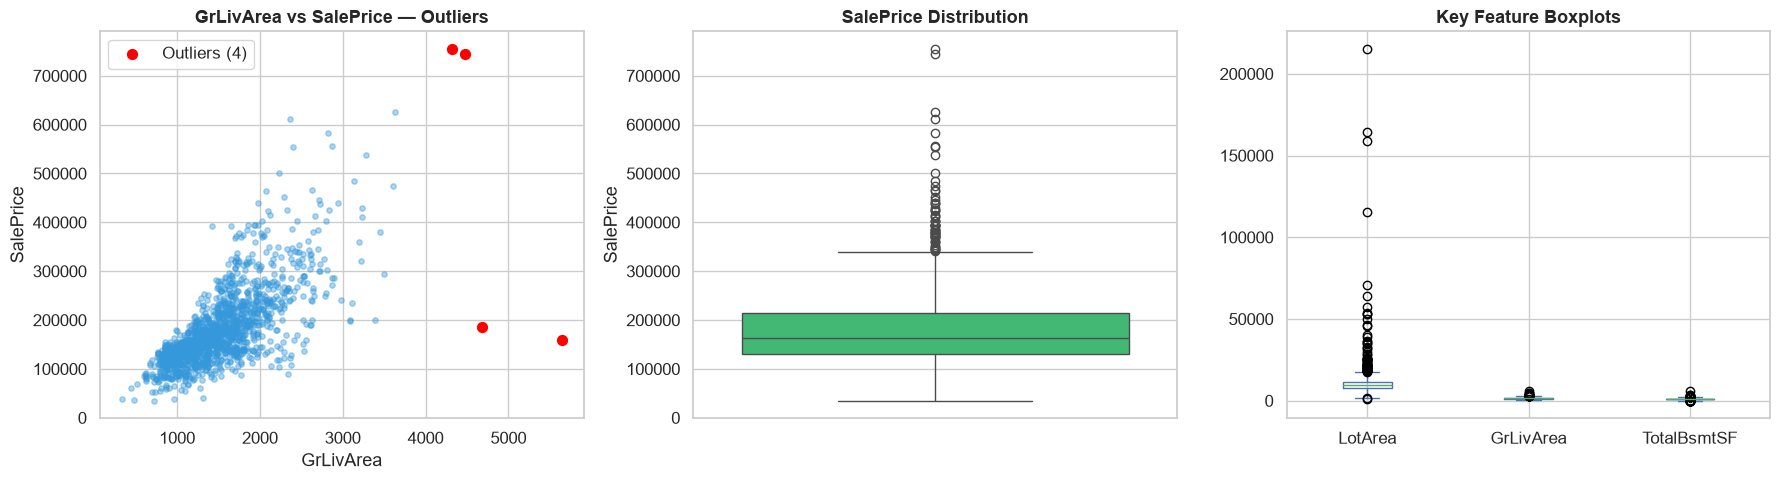

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# GrLivArea outliers
axes[0].scatter(df["GrLivArea"], df["SalePrice"], alpha=0.4, s=15, color="#3498db")
outlier_mask = df["GrLivArea"] > 4000
axes[0].scatter(df.loc[outlier_mask, "GrLivArea"], df.loc[outlier_mask, "SalePrice"],
                color="red", s=50, zorder=5, label=f"Outliers ({outlier_mask.sum()})")
axes[0].set_xlabel("GrLivArea")
axes[0].set_ylabel("SalePrice")
axes[0].set_title("GrLivArea vs SalePrice — Outliers", fontweight="bold")
axes[0].legend()

# SalePrice boxplot
sns.boxplot(y=df["SalePrice"], ax=axes[1], color="#2ecc71")
axes[1].set_title("SalePrice Distribution", fontweight="bold")

# Key feature boxplots
df[["LotArea", "GrLivArea", "TotalBsmtSF"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Key Feature Boxplots", fontweight="bold")

plt.tight_layout()
plt.show()

**Outlier observations:**
- Two houses with GrLivArea > 4000 sqft have low prices — potential data quality issues
- SalePrice has several high-value outliers above $400K
- LotArea has extreme outliers

→ We use **RobustScaler** instead of StandardScaler to reduce outlier sensitivity
in the preprocessing pipeline.

---
## 6. EDA Findings & Modeling Decisions

| Finding | Modeling Decision |
|---|---|
| Target is right-skewed | Experiment with log1p transformation |
| NaN = absence of feature | Apply domain-aware NaN handling before pipeline |
| OverallQual & GrLivArea are top predictors | Create QualArea interaction feature |
| Multiple area columns exist | Create TotalSF aggregate feature |
| Multiple bathroom columns exist | Create TotalBathrooms aggregate feature |
| Outliers in area and price | Use RobustScaler instead of StandardScaler |
| Many categorical features | Use OneHotEncoder inside pipeline |
| LotFrontage genuinely missing | Use median imputation inside pipeline |

---
## 7. Feature Engineering

We create domain-driven features using only columns that actually exist in the dataset.
Every new feature is validated before creation.

### 7.1 Semantic Missing Value Handling

In [15]:
# Categorical features where NaN means "this house lacks the feature"
none_cats = [
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
    "BsmtFinType2", "FireplaceQu", "GarageType", "GarageFinish",
    "GarageQual", "GarageCond", "PoolQC", "Fence", "MiscFeature", "MasVnrType",
]
for col in none_cats:
    if col in df.columns:
        df[col] = df[col].fillna("None")

# Numerical features where NaN means 0 (absence of area/count)
zero_nums = [
    "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath", "GarageCars", "GarageArea", "GarageYrBlt",
]
for col in zero_nums:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Electrical: only 1 missing → fill with mode
if "Electrical" in df.columns:
    df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

# Remaining missing values (LotFrontage) handled by pipeline's median imputer
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
print(f"Remaining features with missing values: {len(remaining)}")
if len(remaining) > 0:
    print(remaining.sort_values(ascending=False))

Remaining features with missing values: 1
LotFrontage    259
dtype: int64


### 7.2 Engineered Features

In [16]:
def safe_feature(df, name, required_cols, func):
    """Create a feature only if all required columns exist."""
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print(f"  ⚠ Skipping '{name}': missing columns {missing}")
        return df
    df[name] = func(df)
    print(f"  ✓ Created '{name}'")
    return df

print("Creating engineered features:\n")

# Area features
df = safe_feature(df, "TotalSF",
    ["TotalBsmtSF", "1stFlrSF", "2ndFlrSF"],
    lambda d: d["TotalBsmtSF"] + d["1stFlrSF"] + d["2ndFlrSF"])

df = safe_feature(df, "TotalPorchSF",
    ["WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch"],
    lambda d: d["WoodDeckSF"] + d["OpenPorchSF"] + d["EnclosedPorch"]
              + d["3SsnPorch"] + d["ScreenPorch"])

# Bathroom count
df = safe_feature(df, "TotalBathrooms",
    ["FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath"],
    lambda d: d["FullBath"] + 0.5 * d["HalfBath"]
              + d["BsmtFullBath"] + 0.5 * d["BsmtHalfBath"])

# Age features
df = safe_feature(df, "HouseAge", ["YrSold", "YearBuilt"],
    lambda d: d["YrSold"] - d["YearBuilt"])

df = safe_feature(df, "RemodAge", ["YrSold", "YearRemodAdd"],
    lambda d: d["YrSold"] - d["YearRemodAdd"])

# Binary indicators
df = safe_feature(df, "HasGarage", ["GarageArea"],
    lambda d: (d["GarageArea"] > 0).astype(int))
df = safe_feature(df, "HasBasement", ["TotalBsmtSF"],
    lambda d: (d["TotalBsmtSF"] > 0).astype(int))
df = safe_feature(df, "HasFireplace", ["Fireplaces"],
    lambda d: (d["Fireplaces"] > 0).astype(int))
df = safe_feature(df, "HasPool", ["PoolArea"],
    lambda d: (d["PoolArea"] > 0).astype(int))
df = safe_feature(df, "Has2ndFloor", ["2ndFlrSF"],
    lambda d: (d["2ndFlrSF"] > 0).astype(int))

# Quality × Area interaction
df = safe_feature(df, "QualArea", ["OverallQual", "GrLivArea"],
    lambda d: d["OverallQual"] * d["GrLivArea"])

print(f"\nDataset shape after feature engineering: {df.shape}")

Creating engineered features:

  ✓ Created 'TotalSF'
  ✓ Created 'TotalPorchSF'
  ✓ Created 'TotalBathrooms'
  ✓ Created 'HouseAge'
  ✓ Created 'RemodAge'
  ✓ Created 'HasGarage'
  ✓ Created 'HasBasement'
  ✓ Created 'HasFireplace'
  ✓ Created 'HasPool'
  ✓ Created 'Has2ndFloor'
  ✓ Created 'QualArea'

Dataset shape after feature engineering: (1460, 92)


---
## 8. Data Preparation

### 8.1 Separate Features and Target

In [17]:
X = df.drop(columns=["SalePrice", "Id"])
y = df["SalePrice"]

print(f"Features: {X.shape[1]} columns")
print(f"Target:   {len(y)} values")

Features: 90 columns
Target:   1460 values


### 8.2 Train / Test Split

We hold out 20% of the data as an untouched test set for final evaluation.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE,
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 1168
Testing samples:  292


### 8.3 Preprocessing Pipeline

All learned transformations are inside the pipeline to prevent data leakage.

- **Numerical**: median imputation → RobustScaler
- **Categorical**: constant imputation ("Missing") → OneHotEncoder

In [19]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numerical features:   {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
], remainder="drop")

print("\n✓ Preprocessing pipeline built (leakage-safe)")

Numerical features:   47
Categorical features: 43

✓ Preprocessing pipeline built (leakage-safe)


---
## 9. Target Transformation Experiment

We compare training with **raw SalePrice** vs. **log1p(SalePrice)** using
cross-validation on representative models. The log transformation may help
because the target is right-skewed.

In [20]:
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

test_models = {
    "Ridge": Ridge(alpha=10, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE),
}

print(f"{'Model':<22s} {'Raw RMSE':>12s} {'Log RMSE':>12s} {'Winner':>10s}")
print("-" * 60)

raw_wins = 0
log_wins = 0

for name, model in test_models.items():
    raw_pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    log_pipe = TransformedTargetRegressor(
        regressor=Pipeline([("preprocessor", preprocessor), ("model", model)]),
        func=np.log1p, inverse_func=np.expm1,
    )
    raw_scores = cross_validate(raw_pipe, X_train, y_train, cv=kf,
                                scoring="neg_root_mean_squared_error", n_jobs=-1)
    log_scores = cross_validate(log_pipe, X_train, y_train, cv=kf,
                                scoring="neg_root_mean_squared_error", n_jobs=-1)
    raw_rmse = -raw_scores["test_score"].mean()
    log_rmse = -log_scores["test_score"].mean()
    winner = "log1p" if log_rmse < raw_rmse else "raw"
    if winner == "log1p":
        log_wins += 1
    else:
        raw_wins += 1
    print(f"{name:<22s} ${raw_rmse:>10,.0f} ${log_rmse:>10,.0f} {winner:>10s}")

use_log_target = log_wins > raw_wins
transform_label = "log1p(SalePrice)" if use_log_target else "raw SalePrice"
print(f"\n✓ Decision: Using **{transform_label}** based on {N_SPLITS}-fold CV results.")

Model                      Raw RMSE     Log RMSE     Winner
------------------------------------------------------------


Ridge                  $    31,979 $    39,950        raw
Random Forest          $    29,303 $    29,422        raw
Gradient Boosting      $    26,357 $    26,200      log1p

✓ Decision: Using **raw SalePrice** based on 5-fold CV results.


---
## 10. Baseline Model — Linear Regression

Before benchmarking all models, we establish a baseline with Linear Regression.

In [21]:
baseline_pipe = Pipeline([("preprocessor", preprocessor), ("model", LinearRegression())])

if use_log_target:
    baseline_estimator = TransformedTargetRegressor(
        regressor=baseline_pipe, func=np.log1p, inverse_func=np.expm1,
    )
else:
    baseline_estimator = baseline_pipe

baseline_estimator.fit(X_train, y_train)
y_pred_baseline = baseline_estimator.predict(X_test)

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = root_mean_squared_error(y_test, y_pred_baseline)
baseline_r2 = r2_score(y_test, y_pred_baseline)

print("Baseline — Linear Regression (Test Set)")
print("=" * 40)
print(f"  MAE  : ${baseline_mae:,.2f}")
print(f"  RMSE : ${baseline_rmse:,.2f}")
print(f"  R²   : {baseline_r2:.4f}")

Baseline — Linear Regression (Test Set)
  MAE  : $19,583.57
  RMSE : $57,423.06
  R²   : 0.5701


---
## 11. Model Benchmarking with Cross-Validation

We benchmark **12 regression algorithms** using 5-fold cross-validation.
Every model uses the same preprocessing pipeline and train/test split.
All metrics are computed in the original SalePrice scale.

In [22]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=10, random_state=RANDOM_STATE),
    "Lasso": Lasso(alpha=1.0, random_state=RANDOM_STATE, max_iter=5000),
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=5000),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=200, random_state=RANDOM_STATE),
    "KNN": KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    "SVR": SVR(kernel="rbf"),
}

if HAS_XGBOOST:
    models["XGBoost"] = XGBRegressor(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    )

print(f"Benchmarking {len(models)} models with {N_SPLITS}-fold CV...")
print(f"Target: {transform_label}\n")
print(f"{'Model':<25s} {'CV MAE':>10s} {'CV RMSE':>10s} {'CV R²':>8s}")
print("-" * 57)

cv_results = []

for name, model in models.items():
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", model)])
    if use_log_target:
        estimator = TransformedTargetRegressor(
            regressor=pipeline, func=np.log1p, inverse_func=np.expm1,
        )
    else:
        estimator = pipeline

    scores = cross_validate(
        estimator, X_train, y_train, cv=kf,
        scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"],
        n_jobs=-1, return_train_score=False,
    )
    mae = -scores["test_neg_mean_absolute_error"].mean()
    rmse = -scores["test_neg_root_mean_squared_error"].mean()
    r2 = scores["test_r2"].mean()

    cv_results.append({"Model": name, "CV MAE": mae, "CV RMSE": rmse, "CV R²": r2})
    print(f"{name:<25s} ${mae:>9,.0f} ${rmse:>9,.0f} {r2:>8.4f}")

results_df = pd.DataFrame(cv_results).sort_values("CV RMSE").reset_index(drop=True)
print(f"\n✓ Benchmarking complete.")

Benchmarking 12 models with 5-fold CV...
Target: raw SalePrice

Model                         CV MAE    CV RMSE    CV R²
---------------------------------------------------------
Linear Regression         $   18,907 $   39,600   0.7141
Ridge                     $   18,065 $   31,979   0.8234
Lasso                     $   18,675 $   37,828   0.7467
ElasticNet                $   19,557 $   34,528   0.7971
Decision Tree             $   26,352 $   42,267   0.6973
Random Forest             $   17,620 $   29,353   0.8535
Extra Trees               $   16,885 $   28,813   0.8584
Gradient Boosting         $   15,407 $   25,964   0.8846
HistGradientBoosting      $   16,961 $   28,429   0.8629
KNN                       $   29,451 $   48,678   0.5960
SVR                       $   54,585 $   78,860  -0.0459
XGBoost                   $   17,199 $   28,466   0.8628

✓ Benchmarking complete.


In [23]:
# Display results sorted by CV RMSE
results_df

,Model,CV MAE,CV RMSE,CV R²
0,Gradient Boosting,15407.168363,25963.513079,0.884558
1,HistGradientBoosting,16961.260616,28428.821236,0.862876
2,XGBoost,17198.613281,28466.395313,0.862812
3,Extra Trees,16884.683025,28812.912089,0.858418
4,Random Forest,17619.833645,29353.300067,0.853532
5,Ridge,18064.980899,31978.740778,0.823370
6,ElasticNet,19556.829592,34528.454019,0.797067
7,Lasso,18675.480357,37827.868730,0.746659
8,Linear Regression,18907.326747,39600.409634,0.714070
9,Decision Tree,26351.730267,42267.135901,0.697343


---
## 12. Visual Model Comparison

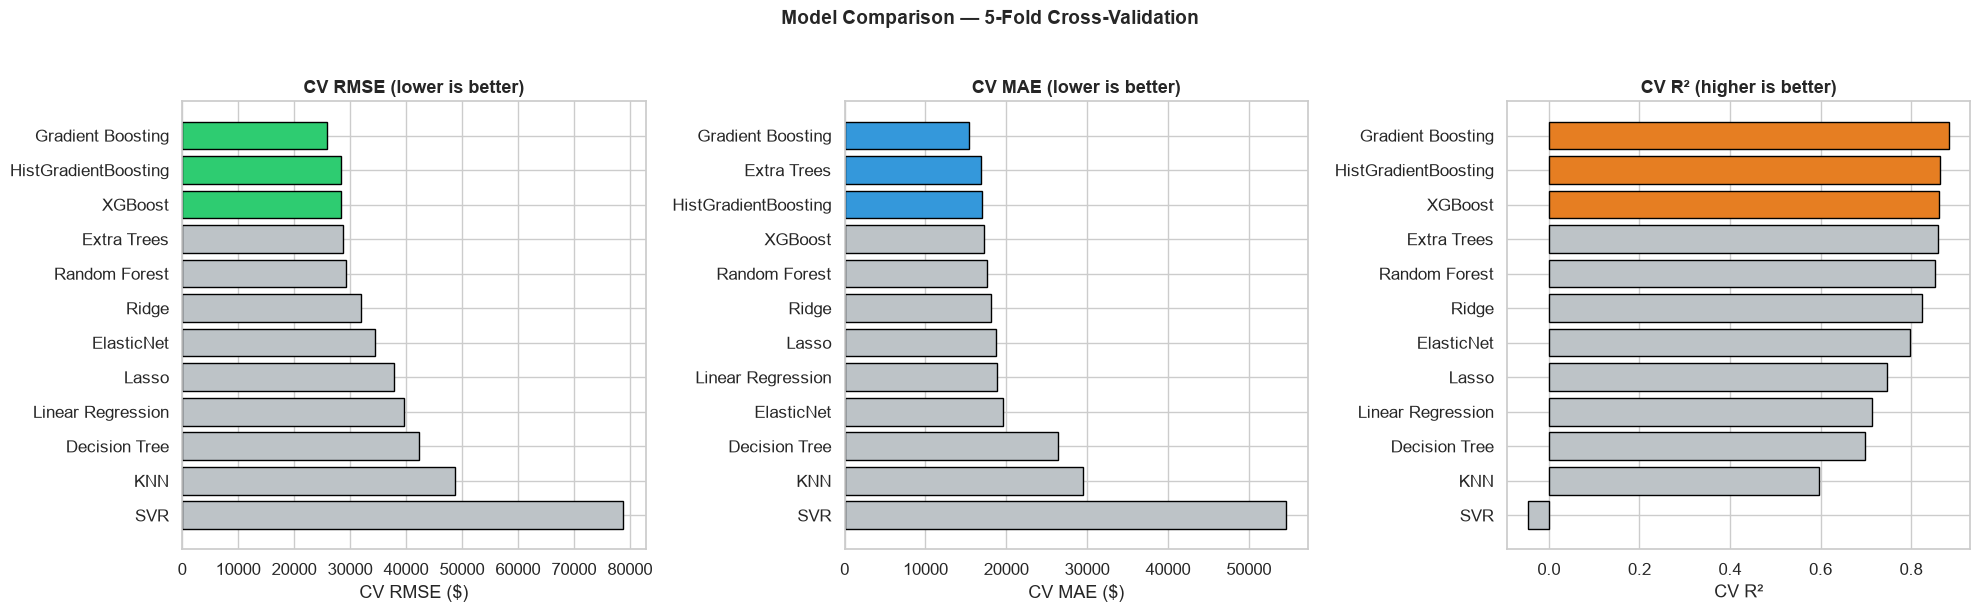

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# RMSE
rs = results_df.sort_values("CV RMSE")
colors = ["#2ecc71" if i < 3 else "#bdc3c7" for i in range(len(rs))]
axes[0].barh(rs["Model"], rs["CV RMSE"], color=colors, edgecolor="black")
axes[0].set_xlabel("CV RMSE ($)")
axes[0].set_title("CV RMSE (lower is better)", fontweight="bold")
axes[0].invert_yaxis()

# MAE
rm = results_df.sort_values("CV MAE")
colors_m = ["#3498db" if i < 3 else "#bdc3c7" for i in range(len(rm))]
axes[1].barh(rm["Model"], rm["CV MAE"], color=colors_m, edgecolor="black")
axes[1].set_xlabel("CV MAE ($)")
axes[1].set_title("CV MAE (lower is better)", fontweight="bold")
axes[1].invert_yaxis()

# R²
rr = results_df.sort_values("CV R²", ascending=False)
colors_r = ["#e67e22" if i < 3 else "#bdc3c7" for i in range(len(rr))]
axes[2].barh(rr["Model"], rr["CV R²"], color=colors_r, edgecolor="black")
axes[2].set_xlabel("CV R²")
axes[2].set_title("CV R² (higher is better)", fontweight="bold")
axes[2].invert_yaxis()

plt.suptitle("Model Comparison — 5-Fold Cross-Validation", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

The **top 3 models** (green bars) are selected for hyperparameter tuning in the next section.
The ranking is determined entirely by CV RMSE — not assumed beforehand.

---
## 13. Hyperparameter Tuning

We tune the **actual top 3 models** from the benchmark using `RandomizedSearchCV`
with the same 5-fold CV strategy.

In [25]:
top3_names = results_df.head(3)["Model"].tolist()
print(f"Top 3 models to tune: {top3_names}\n")

# Define hyperparameter search spaces
param_grids = {
    "Linear Regression": {},
    "Ridge": {"model__alpha": [0.01, 0.1, 1, 5, 10, 50, 100, 500]},
    "Lasso": {"model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]},
    "ElasticNet": {
        "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
    },
    "Decision Tree": {
        "model__max_depth": [5, 10, 15, 20, 25, None],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf": [1, 2, 4, 8],
    },
    "Random Forest": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [10, 15, 20, 25, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
    },
    "Extra Trees": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [10, 15, 20, 25, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__max_depth": [3, 4, 5, 6],
        "model__subsample": [0.8, 0.9, 1.0],
    },
    "HistGradientBoosting": {
        "model__max_iter": [100, 200, 300, 500],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__max_depth": [3, 5, 7, None],
        "model__min_samples_leaf": [10, 20, 30],
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11, 15, 20],
        "model__weights": ["uniform", "distance"],
    },
    "SVR": {
        "model__C": [0.1, 1, 10, 100],
        "model__epsilon": [0.01, 0.1, 0.5],
    },
}

if HAS_XGBOOST:
    param_grids["XGBoost"] = {
        "model__n_estimators": [100, 200, 300, 500],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__max_depth": [3, 5, 7, 9],
        "model__subsample": [0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    }

Top 3 models to tune: ['Gradient Boosting', 'HistGradientBoosting', 'XGBoost']



In [27]:
tuning_results = []

best_model = None
best_model_name = None
best_tuned_rmse = float("inf")

tuning_kf = KFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

for name in top3_names:

    print("=" * 60)
    print(f"Tuning: {name}")
    print("=" * 60)

    model = models[name]
    base_params = param_grids.get(name, {})

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    if use_log_target:

        estimator = TransformedTargetRegressor(
            regressor=pipeline,
            func=np.log1p,
            inverse_func=np.expm1
        )

        params = {
            f"regressor__{k}": v
            for k, v in base_params.items()
        }

    else:

        estimator = pipeline
        params = base_params

    # Original benchmark RMSE
    original_rmse = results_df.loc[
        results_df["Model"] == name,
        "CV RMSE"
    ].values[0]

    if not params:

        print("No hyperparameters to tune.")
        print("Using default configuration.")

        scores = cross_validate(
            estimator,
            X_train,
            y_train,
            cv=tuning_kf,
            scoring="neg_root_mean_squared_error",
            n_jobs=1
        )

        tuned_rmse = -scores["test_score"].mean()

        tuning_results.append({
            "Model": name,
            "CV RMSE (before)": original_rmse,
            "CV RMSE (after)": tuned_rmse,
            "Improvement": original_rmse - tuned_rmse,
            "Best Params": "default"
        })

        if tuned_rmse < best_tuned_rmse:

            best_tuned_rmse = tuned_rmse

            best_model = clone(estimator).fit(
                X_train,
                y_train
            )

            best_model_name = name

        print(f"CV RMSE: ${tuned_rmse:,.0f}\n")

        continue

    total_combos = reduce(
        mul,
        (len(v) for v in params.values()),
        1
    )

    # Only 5 configurations
    n_iter = min(5, total_combos)

    print(f"Total possible combinations: {total_combos}")
    print(f"Testing {n_iter} random configurations")
    print("Using 3-fold CV")
    print("Parallel jobs: 1\n")

    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=params,
        n_iter=n_iter,
        cv=tuning_kf,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_STATE,

        # IMPORTANT:
        # Do not use -1 here because the individual
        # tree models may already use multiple CPU cores.
        n_jobs=1,

        verbose=1,
        return_train_score=False
    )

    search.fit(X_train, y_train)

    tuned_rmse = -search.best_score_

    improvement = original_rmse - tuned_rmse

    print()
    print(f"Before tuning : ${original_rmse:,.0f}")
    print(f"After tuning  : ${tuned_rmse:,.0f}")
    print(f"Improvement    : ${improvement:,.0f}")
    print(f"Best params   : {search.best_params_}")
    print()

    tuning_results.append({
        "Model": name,
        "CV RMSE (before)": original_rmse,
        "CV RMSE (after)": tuned_rmse,
        "Improvement": improvement,
        "Best Params": str(search.best_params_)
    })

    if tuned_rmse < best_tuned_rmse:

        best_tuned_rmse = tuned_rmse
        best_model = search.best_estimator_
        best_model_name = name

        print(f"★ Current best model: {best_model_name}")
        print(f"★ RMSE: ${best_tuned_rmse:,.0f}")

    print("-" * 60)


print("\n" + "=" * 60)
print("TUNING COMPLETE")
print("=" * 60)

print(f"Best model : {best_model_name}")
print(f"CV RMSE   : ${best_tuned_rmse:,.0f}")

Tuning: Gradient Boosting
Total possible combinations: 192
Testing 5 random configurations
Using 3-fold CV
Parallel jobs: 1

Fitting 3 folds for each of 5 candidates, totalling 15 fits

Before tuning : $25,964
After tuning  : $29,337
Improvement    : $-3,373
Best params   : {'model__subsample': 0.8, 'model__n_estimators': 500, 'model__max_depth': 6, 'model__learning_rate': 0.01}

★ Current best model: Gradient Boosting
★ RMSE: $29,337
------------------------------------------------------------
Tuning: HistGradientBoosting
Total possible combinations: 192
Testing 5 random configurations
Using 3-fold CV
Parallel jobs: 1

Fitting 3 folds for each of 5 candidates, totalling 15 fits

Before tuning : $28,429
After tuning  : $29,263
Improvement    : $-834
Best params   : {'model__min_samples_leaf': 20, 'model__max_iter': 200, 'model__max_depth': 7, 'model__learning_rate': 0.05}

★ Current best model: HistGradientBoosting
★ RMSE: $29,263
-------------------------------------------------------

In [28]:
# Tuning comparison
tuning_df = pd.DataFrame(tuning_results)
tuning_df

,Model,CV RMSE (before),CV RMSE (after),Improvement,Best Params
0,Gradient Boosting,25963.513079,29336.533185,-3373.020106,"{'model__subsample': 0.8, 'model__n_estimators..."
1,HistGradientBoosting,28428.821236,29262.734454,-833.913218,"{'model__min_samples_leaf': 20, 'model__max_it..."
2,XGBoost,28466.395313,28971.719401,-505.324089,"{'model__subsample': 0.8, 'model__n_estimators..."


---
## 14. Final Model Evaluation

We evaluate the best tuned model **once** on the held-out test set.
The test set was not used for model selection or hyperparameter tuning.

In [29]:
y_pred = best_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = root_mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

print(f"Final Test Evaluation — {best_model_name}")
print("=" * 45)
print(f"  MAE  : ${test_mae:,.2f}")
print(f"  RMSE : ${test_rmse:,.2f}")
print(f"  R²   : {test_r2:.4f}")
print("=" * 45)
print(f"\n  Cross-validation RMSE: ${best_tuned_rmse:,.0f}")
print(f"  Test RMSE:             ${test_rmse:,.0f}")
print(f"  Difference:            ${abs(test_rmse - best_tuned_rmse):,.0f}")
print(f"\n  (Small difference indicates the model generalises well)")

Final Test Evaluation — XGBoost
  MAE  : $15,036.79
  RMSE : $24,339.21
  R²   : 0.9228

  Cross-validation RMSE: $28,972
  Test RMSE:             $24,339
  Difference:            $4,633

  (Small difference indicates the model generalises well)


---
## 15. Error Analysis

### 15.1 Actual vs Predicted

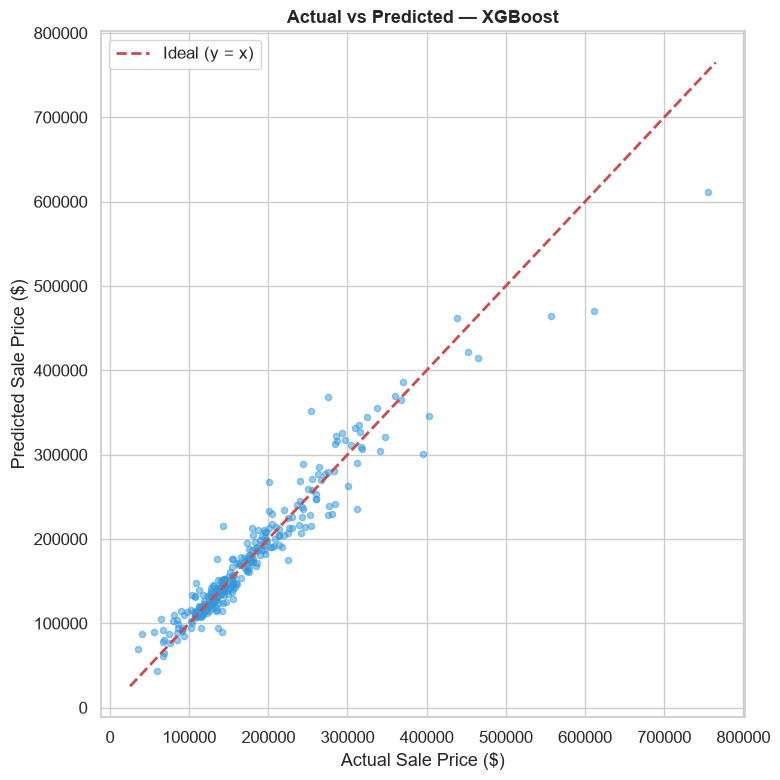

In [30]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred, alpha=0.5, s=20, color="#3498db")
limits = [min(y_test.min(), y_pred.min()) - 10000,
          max(y_test.max(), y_pred.max()) + 10000]
ax.plot(limits, limits, "r--", linewidth=2, label="Ideal (y = x)")
ax.set_xlabel("Actual Sale Price ($)")
ax.set_ylabel("Predicted Sale Price ($)")
ax.set_title(f"Actual vs Predicted — {best_model_name}", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

### 15.2 Residual Analysis

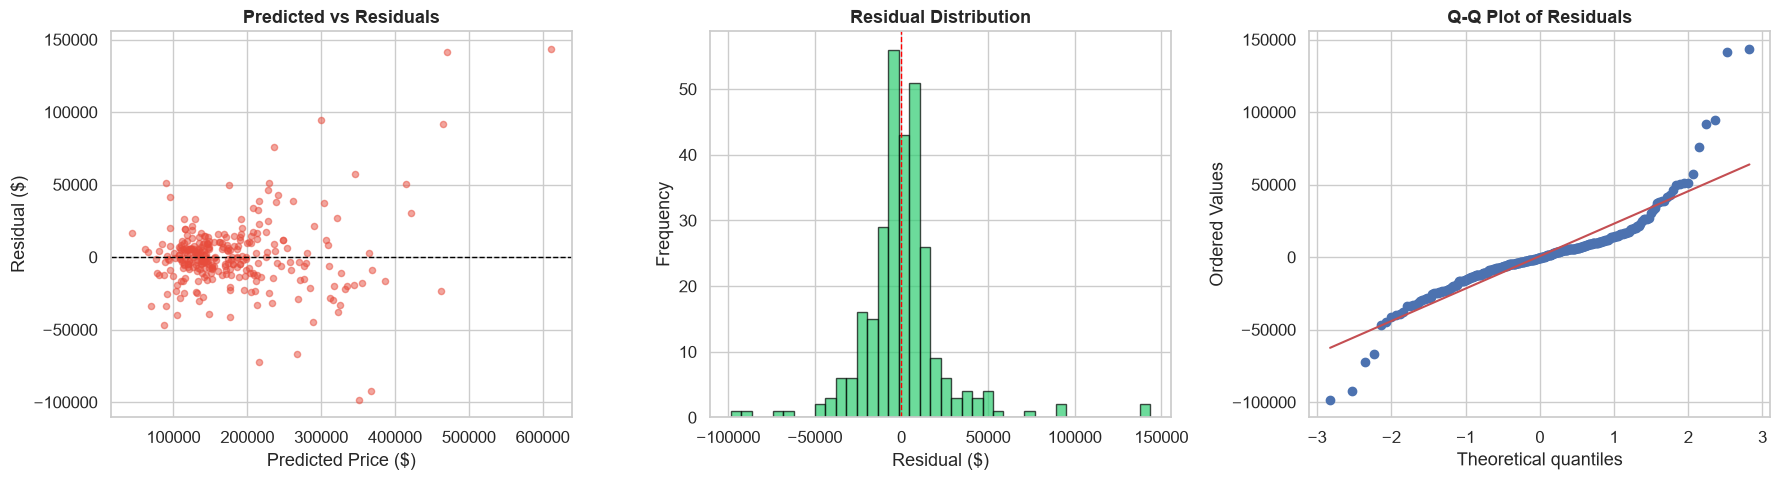

In [31]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Predicted vs Residual
axes[0].scatter(y_pred, residuals, alpha=0.5, s=20, color="#e74c3c")
axes[0].axhline(y=0, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("Predicted Price ($)")
axes[0].set_ylabel("Residual ($)")
axes[0].set_title("Predicted vs Residuals", fontweight="bold")

# Residual Distribution
axes[1].hist(residuals, bins=40, edgecolor="black", color="#2ecc71", alpha=0.7)
axes[1].axvline(x=0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Residual ($)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution", fontweight="bold")

# Q-Q Plot
stats.probplot(residuals, plot=axes[2])
axes[2].set_title("Q-Q Plot of Residuals", fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/residual_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

### 15.3 Worst Predictions

In [32]:
errors = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": np.round(y_pred),
    "Residual": np.round(residuals),
    "Abs Error": np.round(np.abs(residuals)),
    "Pct Error (%)": np.round(np.abs(residuals) / y_test.values * 100, 1),
})
errors = errors.sort_values("Abs Error", ascending=False).reset_index(drop=True)

print("Top 10 Worst Predictions:\n")
errors.head(10)

Top 10 Worst Predictions:



,Actual,Predicted,Residual,Abs Error,Pct Error (%)
0,755000,611390.0,143610.0,143610.0,19.0
1,611657,470029.0,141628.0,141628.0,23.2
2,253293,351747.0,-98454.0,98454.0,38.9
3,395000,300461.0,94539.0,94539.0,23.9
4,276000,367966.0,-91966.0,91966.0,33.3
5,556581,464791.0,91790.0,91790.0,16.5
6,311500,235878.0,75622.0,75622.0,24.3
7,143000,215515.0,-72515.0,72515.0,50.7
8,200624,267186.0,-66562.0,66562.0,33.2
9,403000,345552.0,57448.0,57448.0,14.3


### 15.4 Error by Price Segment

In [33]:
errors["Price Segment"] = pd.cut(
    errors["Actual"],
    bins=[0, 100_000, 150_000, 200_000, 300_000, float("inf")],
    labels=["< $100K", "$100K–$150K", "$150K–$200K", "$200K–$300K", "> $300K"],
)

segment = errors.groupby("Price Segment", observed=True).agg(
    Count=("Abs Error", "count"),
    Mean_Error=("Abs Error", "mean"),
    Median_Error=("Abs Error", "median"),
    Mean_Pct_Error=("Pct Error (%)", "mean"),
).round(0)

segment

,Count,Mean_Error,Median_Error,Mean_Pct_Error
Price Segment,,,,
< $100K,26,15856.0,12815.0,26.0
$100K–$150K,113,9130.0,5628.0,7.0
$150K–$200K,71,9463.0,8747.0,6.0
$200K–$300K,58,22383.0,15844.0,9.0
> $300K,24,40695.0,22590.0,9.0


**Error Analysis Observations:**

- The model predicts well for mid-range houses ($100K–$200K)
- Larger errors occur for expensive houses (> $300K) — likely due to fewer training samples
- Residuals are approximately centered at zero (no systematic bias)
- The Q-Q plot may show deviations in the tails — common for house price data

---
## 16. Feature Importance

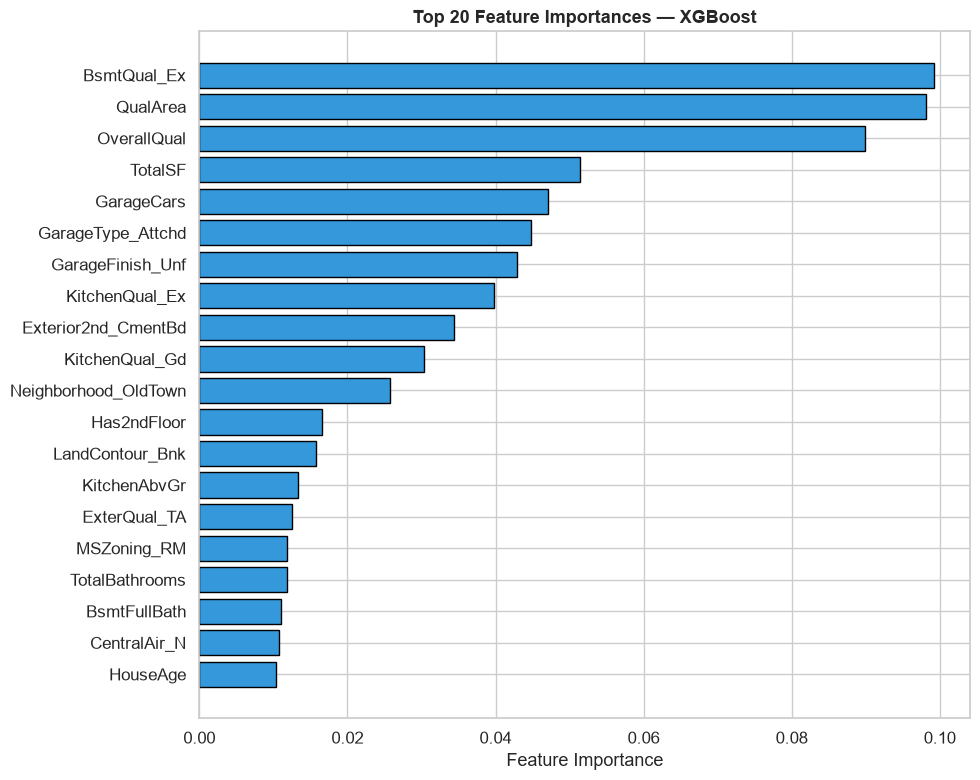

In [34]:
# Extract fitted model from pipeline
if use_log_target:
    inner_pipeline = best_model.regressor_
else:
    inner_pipeline = best_model

fitted_preprocessor = inner_pipeline.named_steps["preprocessor"]
fitted_model_obj = inner_pipeline.named_steps["model"]

# Get feature names
try:
    feature_names = list(fitted_preprocessor.get_feature_names_out())
    feature_names = [n.split("__", 1)[-1] if "__" in n else n for n in feature_names]
except AttributeError:
    n_features = fitted_preprocessor.transform(X_train[:1]).shape[1]
    feature_names = [f"feature_{i}" for i in range(n_features)]

# Plot feature importance
if hasattr(fitted_model_obj, "feature_importances_"):
    importances = fitted_model_obj.feature_importances_
    feat_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    feat_imp = feat_imp.sort_values("Importance", ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(range(len(feat_imp)), feat_imp["Importance"].values,
            color="#3498db", edgecolor="black")
    ax.set_yticks(range(len(feat_imp)))
    ax.set_yticklabels(feat_imp["Feature"].values)
    ax.invert_yaxis()
    ax.set_xlabel("Feature Importance")
    ax.set_title(f"Top 20 Feature Importances — {best_model_name}", fontweight="bold")
    plt.tight_layout()
    plt.savefig("../reports/figures/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
elif hasattr(fitted_model_obj, "coef_"):
    coefs = np.abs(fitted_model_obj.coef_)
    feat_imp = pd.DataFrame({"Feature": feature_names, "Abs Coefficient": coefs})
    feat_imp = feat_imp.sort_values("Abs Coefficient", ascending=False).head(20)
    print("Top 20 features by absolute coefficient:")
    print(feat_imp.to_string(index=False))
else:
    print("Model does not provide feature importances or coefficients.")

---
## 17. SHAP Explainability

SHAP (SHapley Additive exPlanations) provides detailed insight into
how each feature contributes to individual predictions.

Running SHAP analysis for XGBoost...



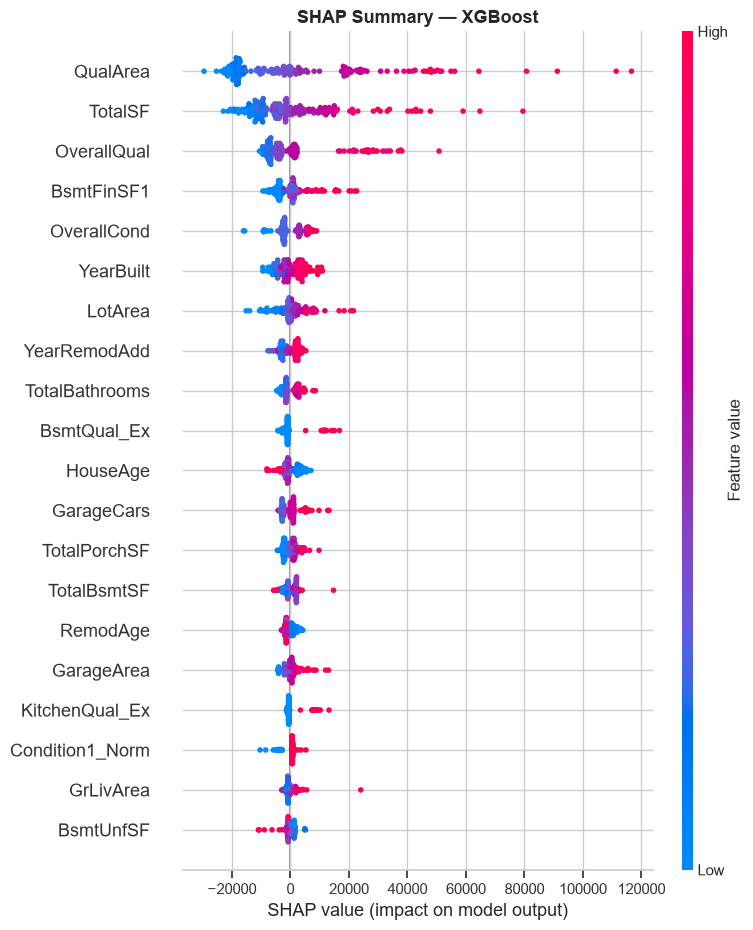

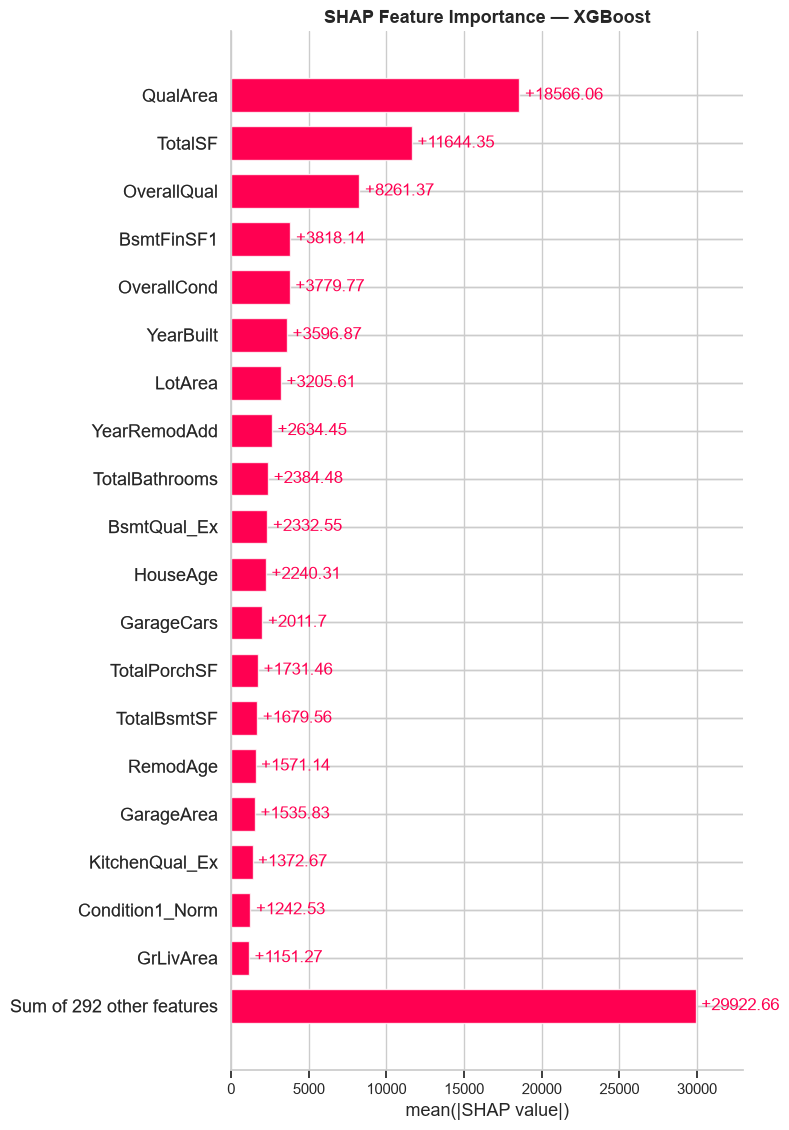

Individual prediction explanations:

--- Observation 0 ---
    Predicted: $142,899
    Actual:    $145,000


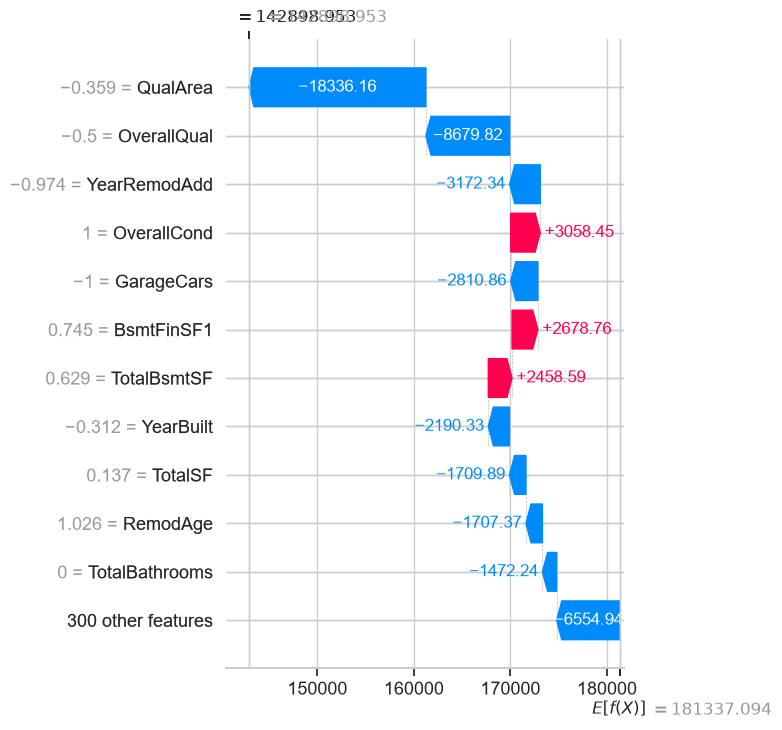

--- Observation 1 ---
    Predicted: $178,514
    Actual:    $178,000


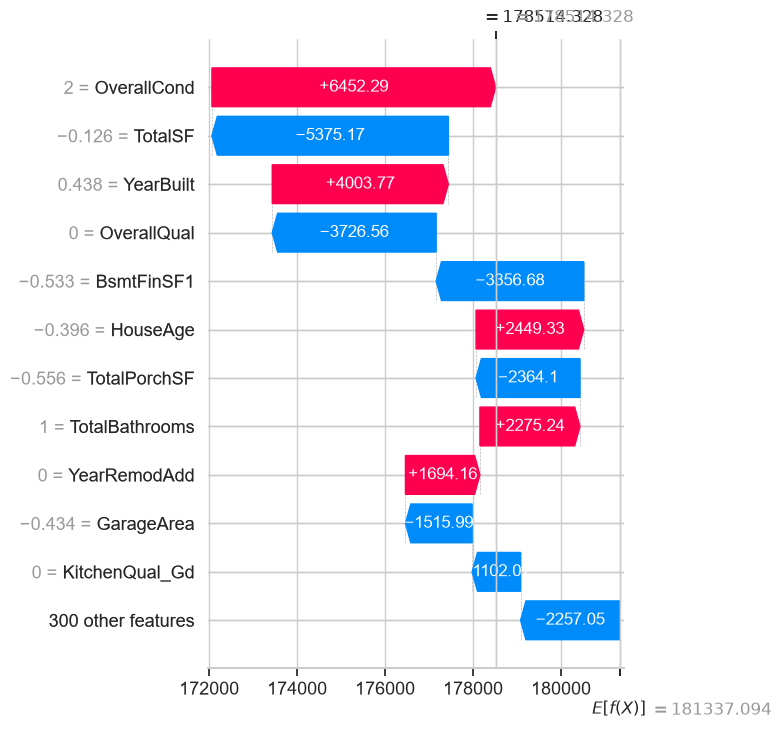

--- Observation 2 ---
    Predicted: $91,801
    Actual:    $85,000


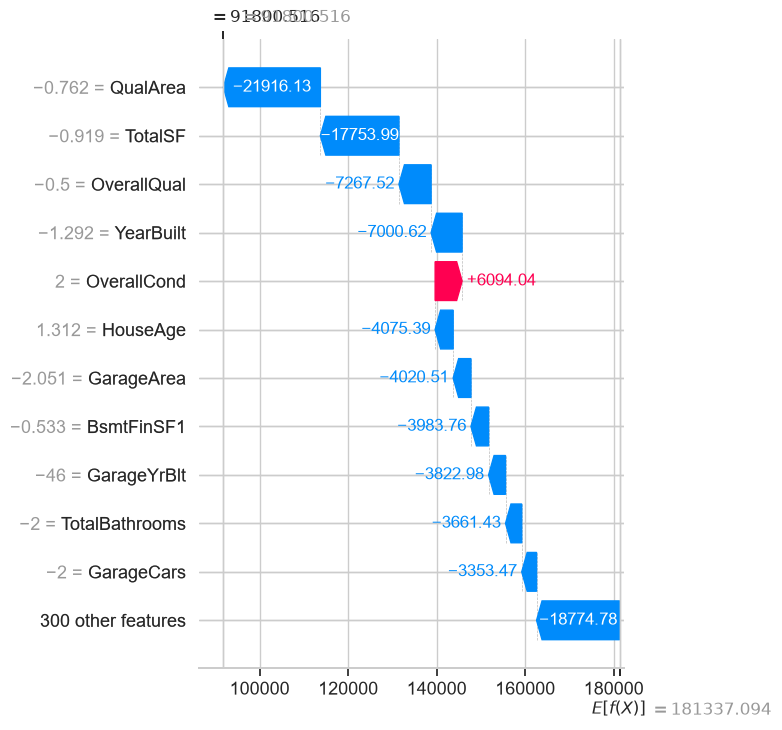

In [35]:
if HAS_SHAP and hasattr(fitted_model_obj, "feature_importances_"):
    print(f"Running SHAP analysis for {best_model_name}...\n")
    try:
        X_train_transformed = fitted_preprocessor.transform(X_train)
        X_train_transformed = np.asarray(X_train_transformed)

        explainer = shap.TreeExplainer(fitted_model_obj)

        sample_size = min(200, len(X_train_transformed))
        X_sample = X_train_transformed[:sample_size]
        shap_values = explainer(X_sample)
        shap_values.feature_names = feature_names

        # Summary plot
        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                          show=False, max_display=20)
        plt.title(f"SHAP Summary — {best_model_name}", fontweight="bold")
        plt.tight_layout()
        plt.savefig("../reports/figures/shap_summary.png", dpi=150, bbox_inches="tight")
        plt.show()

        # Bar plot
        plt.figure(figsize=(10, 8))
        shap.plots.bar(shap_values, max_display=20, show=False)
        plt.title(f"SHAP Feature Importance — {best_model_name}", fontweight="bold")
        plt.tight_layout()
        plt.savefig("../reports/figures/shap_bar.png", dpi=150, bbox_inches="tight")
        plt.show()

        # Individual predictions
        print("Individual prediction explanations:\n")
        for idx in [0, 1, 2]:
            print(f"--- Observation {idx} ---")
            print(f"    Predicted: ${best_model.predict(X_train.iloc[[idx]])[0]:,.0f}")
            print(f"    Actual:    ${y_train.iloc[idx]:,.0f}")
            shap.plots.waterfall(shap_values[idx], max_display=12, show=False)
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"SHAP analysis encountered an error: {e}")
        print("This may happen with certain model configurations.")
elif not HAS_SHAP:
    print("SHAP not available. Install with: pip install shap")
else:
    print(f"SHAP TreeExplainer requires a tree-based model.")
    print(f"Best model ({best_model_name}) does not have feature_importances_.")

---
## 18. Save Model & Results

In [36]:
# Save the best model pipeline
joblib.dump(best_model, "../models/best_model.joblib")
print(f"✓ Model saved: models/best_model.joblib")

# Save model metadata
metadata = {
    "model_name": best_model_name,
    "cv_rmse": round(float(best_tuned_rmse), 2),
    "test_mae": round(float(test_mae), 2),
    "test_rmse": round(float(test_rmse), 2),
    "test_r2": round(float(test_r2), 4),
    "n_features": int(X_train.shape[1]),
    "n_training_samples": int(X_train.shape[0]),
    "n_test_samples": int(X_test.shape[0]),
    "random_state": RANDOM_STATE,
    "cv_folds": N_SPLITS,
    "test_size": TEST_SIZE,
    "use_log_target": bool(use_log_target),
}

with open("../models/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Metadata saved: models/model_metadata.json")

# Save benchmark results
results_df.to_csv("../reports/model_results.csv", index=False)
print(f"✓ Benchmark results saved: reports/model_results.csv")

# Verify saved model loads correctly
loaded = joblib.load("../models/best_model.joblib")
test_pred = loaded.predict(X_test[:3])
print(f"\n✓ Model loads and predicts successfully")
print(f"  Sample predictions: {[f'${p:,.0f}' for p in test_pred]}")

✓ Model saved: models/best_model.joblib
✓ Metadata saved: models/model_metadata.json
✓ Benchmark results saved: reports/model_results.csv

✓ Model loads and predicts successfully
  Sample predictions: ['$145,150', '$344,418', '$109,878']


---
## 19. Final Conclusions

### Summary

This project upgraded a basic Linear Regression house-price model into a
comprehensive comparative ML regression workflow:

1. **EDA** revealed right-skewed target, strong quality/area predictors,
   and semantic meaning in missing values
2. **Feature Engineering** added 11 domain-driven features (TotalSF,
   TotalBathrooms, QualArea, HouseAge, etc.)
3. **12 Regression Models** were benchmarked using 5-fold cross-validation
4. **Hyperparameter Tuning** optimised the top 3 models from actual CV rankings
5. **Error Analysis** showed the model performs well on mid-range houses
   but struggles with high-value properties
6. **SHAP Explainability** identified the key price-driving features

### Key Results

In [38]:
print(f"Best Model:        {best_model_name}")
print(f"Target Transform:  {transform_label}")
print(f"CV RMSE:           ${best_tuned_rmse:,.0f}")
print(f"Test RMSE:         ${test_rmse:,.0f}")
print(f"Test MAE:          ${test_mae:,.0f}")
print(f"Test R²:           {test_r2:.4f}")
print(f"\nFull benchmark results saved to: reports/model_results.csv")
print(f"Best model saved to: models/best_model.joblib")

Best Model:        XGBoost
Target Transform:  raw SalePrice
CV RMSE:           $28,972
Test RMSE:         $24,339
Test MAE:          $15,037
Test R²:           0.9228

Full benchmark results saved to: reports/model_results.csv
Best model saved to: models/best_model.joblib
